# LendingClub Credit Risk — Approval-Cutoff Strategy

Turns the `fico_percentile` credit scorecard (see `scorecard.ipynb`) into an actual
**business decision**: where to set an approval cutoff, and what that decision is
worth in dollars.

This notebook rebuilds the identical scorecard from scratch (same features, same
out-of-time split, same WOE bins) so it stands on its own, then evaluates cutoff
strategies against **realized historical cash flow** — actual dollars paid back
minus dollars funded — rather than an assumed loss-given-default. That real
cash-flow data (`total_pymnt`, `funded_amnt`) is only available after a loan
resolves, so it is used here purely to evaluate *what a cutoff would have been
worth in hindsight*, never as a model input (that would be leakage in the
classifier itself, though it's exactly the right ground truth for retrospective
policy simulation).

**Caveat up front:** this is single-vintage (2016), point-in-time economics. It
ignores funding cost, servicing/operations cost, and macro-cycle effects — a real
deployment decision would need those layered on top.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load data

Same columns as `scorecard.ipynb`, plus `funded_amnt` and `total_pymnt` for the realized-profit calculation below.

In [2]:
usecols = [
    "loan_amnt", "funded_amnt", "total_pymnt", "term", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 23)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)
resolved["net_profit"] = resolved["total_pymnt"] - resolved["funded_amnt"]

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
test_total_profit = test["net_profit"].sum()
test_avg_profit = test["net_profit"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")
print(f"Test accept-all realized net profit: ${test_total_profit:,.0f} (${test_avg_profit:,.0f} per loan on average)")

Train (issued < 2016): 826,606 loans, default rate 18.43%
Test  (issued 2016)  : 293,105 loans, default rate 23.29%
Test accept-all realized net profit: $-71,700,213 ($-245 per loan on average)


## 2. FICO as a rolling-percentile feature

Same construction as `scorecard.ipynb` — percentile rank against a trailing 6-month window of prior originations, for robustness to bureau score revamps (see that notebook for the full rationale).

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

## 3. WOE binning, feature selection, and logistic regression

Identical methodology to `scorecard.ipynb`: bins/groupings fit on train only, IV-based feature selection, WOE-transformed logistic regression.

In [5]:
NUMERIC_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "delinq_2yrs", "fico_percentile",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "emp_length_years",
]
CATEGORICAL_FEATURES = ["home_ownership", "verification_status", "purpose", "term_months"]

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges, cat_groups, woe_tables, iv_summary = {}, {}, {}, {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
SELECTED_FEATURES = iv_series[iv_series >= 0.02].index.tolist()
print("Selected features:", SELECTED_FEATURES)

Selected features: ['term_months', 'fico_percentile', 'dti', 'verification_status', 'loan_amnt', 'annual_inc', 'mort_acc', 'revol_util', 'home_ownership']


In [6]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        out[feat] = binned.map(woe_tab["woe"]).fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
print(coef_table)
bad_sign = coef_table[coef_table > 0]
print("Unexpected positive coefficients:" if len(bad_sign) else "All coefficients negative as expected.", list(bad_sign.index))

Intercept: -1.4883106983822099
fico_percentile       -0.999069
term_months           -0.982830
annual_inc            -0.832081
home_ownership        -0.731839
dti                   -0.679933
mort_acc              -0.655517
verification_status   -0.426816
loan_amnt             -0.424396
revol_util             0.356672
dtype: float64
Unexpected positive coefficients: ['revol_util']


## 4. Score the out-of-time test set

In [7]:
BASE_SCORE, BASE_ODDS, PDO = 600, 50, 20
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def compute_scores(X_woe):
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    return offset - factor * log_odds_bad

train["score"] = compute_scores(X_train)
test["score"] = compute_scores(X_test)

# quick sanity check consistent with scorecard.ipynb: higher score -> lower default rate
direction_check = train.groupby(pd.qcut(train["score"], 5, duplicates="drop"), observed=True)["is_default"].mean()
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted."

from sklearn.metrics import roc_auc_score
test_auc = roc_auc_score(y_test, -test["score"])  # score predicts GOOD, so flip for a "bad" AUC check
print(f"Out-of-time test AUC (consistency check vs. scorecard.ipynb): {test_auc:.4f}")
print(test["score"].describe())

Out-of-time test AUC (consistency check vs. scorecard.ipynb): 0.6763
count    293105.000000
mean        535.044345
std          19.723752
min         463.142154
25%         523.355787
50%         535.326040
75%         547.609398
max         596.711408
Name: score, dtype: float64


## 5. Approval-cutoff strategy curves

For a range of candidate cutoff scores, approve everything scoring at or above the
cutoff and measure, on the out-of-time (2016) test set:

- **Approval rate** — share of applicants accepted
- **Bad rate among approved** — default rate of the accepted population
- **Total realized portfolio profit** — actual dollars paid back minus dollars funded, summed over approved loans

In [8]:
cutoffs = np.quantile(test["score"], np.linspace(0.0, 0.97, 40))

rows = []
for c in cutoffs:
    approved = test[test["score"] >= c]
    if len(approved) == 0:
        continue
    rows.append({
        "cutoff": c,
        "approval_rate": len(approved) / len(test),
        "bad_rate_approved": approved["is_default"].mean(),
        "total_profit": approved["net_profit"].sum(),
        "profit_per_loan": approved["net_profit"].mean(),
    })

strategy_curve = pd.DataFrame(rows)
baseline_profit = test["net_profit"].sum()
best_row = strategy_curve.loc[strategy_curve["total_profit"].idxmax()]

best_cutoff = best_row["cutoff"]
best_approval_rate = best_row["approval_rate"]
best_bad_rate = best_row["bad_rate_approved"]
best_total_profit = best_row["total_profit"]
profit_swing = best_total_profit - baseline_profit

print(f"Accept-all (no cutoff) baseline profit: ${baseline_profit:,.0f}")
print(f"Profit-maximizing cutoff on 2016 test data: score >= {best_cutoff:.1f}")
print(f"  -> approval rate {best_approval_rate:.1%}, bad rate {best_bad_rate:.1%}, total profit ${best_total_profit:,.0f}")
print(f"  -> ${profit_swing:,.0f} swing vs. accept-all "
      "(a % change isn't meaningful here since the accept-all baseline is itself a loss)")

Accept-all (no cutoff) baseline profit: $-71,700,213
Profit-maximizing cutoff on 2016 test data: score >= 534.1
  -> approval rate 52.7%, bad rate 14.9%, total profit $56,046,364
  -> $127,746,577 swing vs. accept-all (a % change isn't meaningful here since the accept-all baseline is itself a loss)


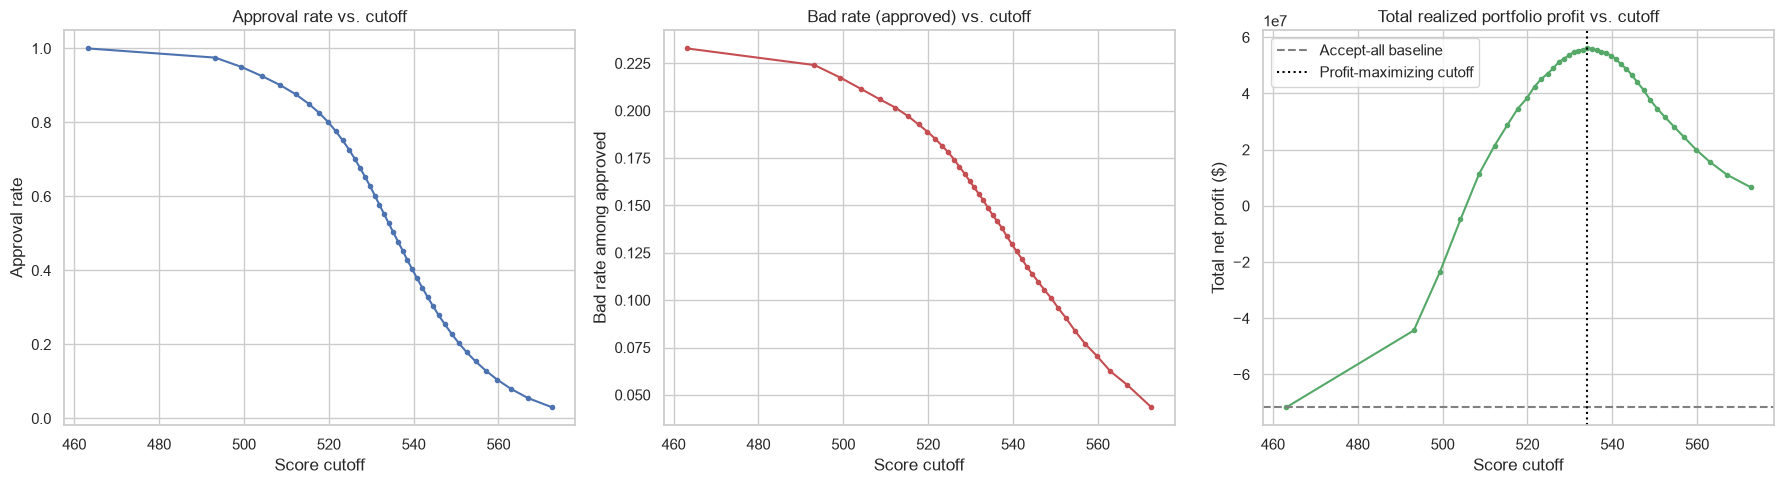

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(strategy_curve["cutoff"], strategy_curve["approval_rate"], marker="o", markersize=3)
axes[0].set_title("Approval rate vs. cutoff")
axes[0].set_xlabel("Score cutoff")
axes[0].set_ylabel("Approval rate")

axes[1].plot(strategy_curve["cutoff"], strategy_curve["bad_rate_approved"], marker="o", markersize=3, color="#C44E52")
axes[1].set_title("Bad rate (approved) vs. cutoff")
axes[1].set_xlabel("Score cutoff")
axes[1].set_ylabel("Bad rate among approved")

axes[2].plot(strategy_curve["cutoff"], strategy_curve["total_profit"], marker="o", markersize=3, color="#55A868")
axes[2].axhline(baseline_profit, linestyle="--", color="grey", label="Accept-all baseline")
axes[2].axvline(best_row["cutoff"], linestyle=":", color="black", label="Profit-maximizing cutoff")
axes[2].set_title("Total realized portfolio profit vs. cutoff")
axes[2].set_xlabel("Score cutoff")
axes[2].set_ylabel("Total net profit ($)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Gains chart: bad-loan capture rate

If loans were declined worst-score-first, what share of *actual bad loans* would be
screened out for a given decline rate? This is the standard way to communicate a
scorecard's separation power to a credit-policy audience.

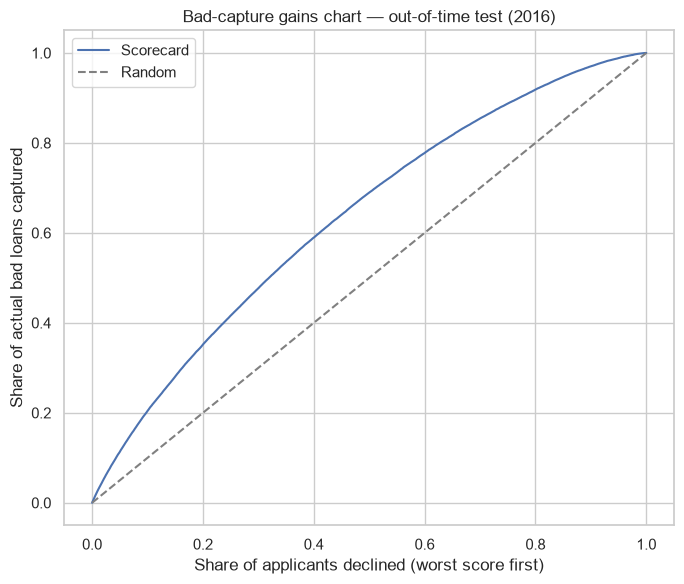

Declining the worst 5% of applicants captures 11.3% of all bad loans.
Declining the worst 10% of applicants captures 20.4% of all bad loans.
Declining the worst 20% of applicants captures 35.2% of all bad loans.
Declining the worst 30% of applicants captures 47.7% of all bad loans.


In [10]:
test_sorted = test.sort_values("score")  # worst score first
test_sorted["cum_declined_share"] = np.arange(1, len(test_sorted) + 1) / len(test_sorted)
test_sorted["cum_bad_captured"] = test_sorted["is_default"].cumsum() / test_sorted["is_default"].sum()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(test_sorted["cum_declined_share"], test_sorted["cum_bad_captured"], label="Scorecard")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax.set_xlabel("Share of applicants declined (worst score first)")
ax.set_ylabel("Share of actual bad loans captured")
ax.set_title("Bad-capture gains chart — out-of-time test (2016)")
ax.legend()
plt.tight_layout()
plt.show()

for decline_share in [0.05, 0.10, 0.20, 0.30]:
    row = test_sorted.iloc[int(len(test_sorted) * decline_share) - 1]
    bad_captured = row["cum_bad_captured"]
    print(f"Declining the worst {decline_share:.0%} of applicants captures {bad_captured:.1%} of all bad loans.")

## 7. Swap-set table at the profit-maximizing cutoff

At the recommended cutoff, what exactly would this policy change relative to
approving everyone? This breaks the score band right around the cutoff into
deciles to show the good/bad mix of loans that a stricter policy would newly
decline.

In [11]:
test["decile"] = pd.qcut(test["score"], 10, labels=False, duplicates="drop")
swap_table = test.groupby("decile", observed=True).agg(
    n=("is_default", "size"),
    avg_score=("score", "mean"),
    bad_rate=("is_default", "mean"),
    total_net_profit=("net_profit", "sum"),
).sort_values("avg_score")

swap_table["decision_at_recommended_cutoff"] = np.where(
    swap_table["avg_score"] >= best_row["cutoff"], "Approve", "Decline"
)
swap_table

,n,avg_score,bad_rate,total_net_profit,decision_at_recommended_cutoff
decile,,,,,
0,29311,498.201808,0.475214,-8.328516e+07,Decline
1,29310,514.985836,0.343876,-2.692692e+07,Decline
2,29311,523.275248,0.291597,-1.068807e+07,Decline
3,29310,528.656777,0.262231,-5.432990e+06,Decline
4,29311,533.143131,0.232745,-1.298018e+06,Decline
5,29310,537.558192,0.204708,2.810065e+06,Approve
6,29310,542.224607,0.179086,6.734551e+06,Approve
7,29311,547.684351,0.149398,1.212943e+07,Approve
8,29310,555.181170,0.120607,1.495539e+07,Approve


Deciles marked **Decline** are score bands where, historically, the loans
booked there lost more money in aggregate than they earned — this is the
swap-out set: real loans LendingClub approved that this policy would not have.
Deciles marked **Approve** are retained.

## 8. Summary & recommendation

- On the 2016 out-of-time test set, the profit-maximizing cutoff is printed in
  Section 5 above, together with the resulting approval rate, bad rate, and dollar
  improvement over an accept-all baseline.
- The gains chart (Section 6) quantifies the scorecard's separation power directly
  in decline-rate terms: e.g. declining the worst 10% of applicants captures a
  disproportionate share of actual bad loans.
- The swap-set table (Section 7) makes the policy concrete: which score bands would
  flip from approved to declined, and what that band's historical loans actually
  cost or earned.
- **Caveats:** this uses realized cash flow from a single vintage (2016) with no
  adjustment for funding cost, servicing cost, or the credit cycle — a deployment
  decision should stress-test the chosen cutoff against a downturn scenario and
  layer in a real cost-of-capital assumption before treating the profit numbers
  above as production-ready.